# Carleman lifting: equal-mass, equal-length double pendulum

The exact four-state model is solved with Para-Seq's RK4 + full DEER path. The lifted linear model uses the explicit total-degree-seven Taylor expansion about the downward equilibrium and the repository's dense associative-scan linear ODE utilities.

The error analysis separates nonlinear numerical error, seventh-order polynomial-model error, and finite-section Carleman error. The lifted state is restarted from its own predicted first block every eight time steps.


In [1]:
from pathlib import Path
import sys
import time
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from scipy.integrate import solve_ivp

repo_root = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "ode_solvers").is_dir()
)
sys.path.insert(0, str(repo_root))

from src.ode_solvers import (
    discretize_lti_zoh,
    linear_affine_scan,
    solve_ode_fixed_step,
)

torch.set_default_dtype(torch.float64)
dtype = torch.float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

print(f"Repository: {repo_root}")
print(f"Device:     {device}")
print(f"Dtype:      {dtype}")


Repository: /mnt/c/Users/Banaan/Documents/Github/IDK/Para-Seq
Device:     cuda
Dtype:      torch.float64


## Exact model and seventh-order polynomial model

Let \(q_1,q_2\) be the angles, \(v_1,v_2\) the angular velocities, and \(d=q_1-q_2\). For unit masses and lengths,

\[
\dot q_1=v_1,\qquad \dot q_2=v_2,
\]

\[
\dot v_1=
\frac{-3g\sin q_1-g\sin(q_1-2q_2)-2\sin d\left(v_2^2+v_1^2\cos d\right)}
{3-\cos(2d)},
\]

\[
\dot v_2=
\frac{2\sin d\left(2v_1^2+2g\cos q_1+v_2^2\cos d\right)}
{3-\cos(2d)}.
\]

The notebook uses the explicit total-degree-seven Taylor polynomial \(f^{(7)}\). For \(z_\alpha=x^\alpha\),

\[
\dot z_\alpha=\sum_{r=1}^4\alpha_r x^{\alpha-e_r}f_r^{(7)}(x).
\]

The degrees \(1,3,5,7\) couple lifted degree \(k\) to \(k,k+2,k+4,k+6\), respectively.


In [2]:
gravity = 9.81
initial_state = np.array([0.10, -0.08, 0.0, 0.0], dtype=np.float64)
final_time = 10.0
num_time_points = 513
carleman_order = 7
carleman_relift_steps = 8

times = np.linspace(0.0, final_time, num_time_points, dtype=np.float64)


def double_pendulum_rhs_torch(time, state, control):
    q1, q2, v1, v2 = state.unbind(dim=-1)
    difference = q1 - q2
    denominator = 3.0 - torch.cos(2.0 * difference)
    acceleration_1 = (
        -3.0 * gravity * torch.sin(q1)
        - gravity * torch.sin(q1 - 2.0 * q2)
        - 2.0 * torch.sin(difference) * (v2**2 + v1**2 * torch.cos(difference))
    ) / denominator
    acceleration_2 = (
        2.0 * torch.sin(difference)
        * (2.0 * v1**2 + 2.0 * gravity * torch.cos(q1) + v2**2 * torch.cos(difference))
    ) / denominator
    return torch.stack((v1, v2, acceleration_1, acceleration_2), dim=-1)


def double_pendulum_rhs_scipy(time, state):
    q1, q2, v1, v2 = state
    difference = q1 - q2
    denominator = 3.0 - np.cos(2.0 * difference)
    acceleration_1 = (
        -3.0 * gravity * np.sin(q1)
        - gravity * np.sin(q1 - 2.0 * q2)
        - 2.0 * np.sin(difference) * (v2**2 + v1**2 * np.cos(difference))
    ) / denominator
    acceleration_2 = (
        2.0 * np.sin(difference)
        * (2.0 * v1**2 + 2.0 * gravity * np.cos(q1) + v2**2 * np.cos(difference))
    ) / denominator
    return np.array((v1, v2, acceleration_1, acceleration_2), dtype=np.float64)


In [3]:
def double_pendulum_exponents(order):
    exponents = []
    for degree in range(1, order + 1):
        exponents.extend(
            exponent
            for exponent in product(range(degree, -1, -1), repeat=4)
            if sum(exponent) == degree
        )
    return exponents


def double_pendulum_polynomial_terms():
    return [
        [
            ((0, 0, 1, 0), 1),
        ],
        [
            ((0, 0, 0, 1), 1),
        ],
        [
            ((7, 0, 0, 0), (9787/2520)*gravity),
            ((6, 1, 0, 0), -17831/720*gravity),
            ((5, 2, 0, 0), (1645/24)*gravity),
            ((5, 0, 2, 0), -32/15),
            ((5, 0, 0, 2), -181/120),
            ((5, 0, 0, 0), -181/60*gravity),
            ((4, 3, 0, 0), -7693/72*gravity),
            ((4, 1, 2, 0), 32/3),
            ((4, 1, 0, 2), 181/24),
            ((4, 1, 0, 0), (317/24)*gravity),
            ((3, 4, 0, 0), (913/9)*gravity),
            ((3, 2, 2, 0), -64/3),
            ((3, 2, 0, 2), -181/12),
            ((3, 2, 0, 0), -143/6*gravity),
            ((3, 0, 2, 0), 5/3),
            ((3, 0, 0, 2), 7/6),
            ((3, 0, 0, 0), (7/3)*gravity),
            ((2, 5, 0, 0), -881/15*gravity),
            ((2, 3, 2, 0), 64/3),
            ((2, 3, 0, 2), 181/12),
            ((2, 3, 0, 0), (133/6)*gravity),
            ((2, 1, 2, 0), -5),
            ((2, 1, 0, 2), -7/2),
            ((2, 1, 0, 0), -11/2*gravity),
            ((1, 6, 0, 0), (173/9)*gravity),
            ((1, 4, 2, 0), -32/3),
            ((1, 4, 0, 2), -181/24),
            ((1, 4, 0, 0), -32/3*gravity),
            ((1, 2, 2, 0), 5),
            ((1, 2, 0, 2), 7/2),
            ((1, 2, 0, 0), 5*gravity),
            ((1, 0, 2, 0), -1),
            ((1, 0, 0, 2), -1),
            ((1, 0, 0, 0), -2*gravity),
            ((0, 7, 0, 0), -173/63*gravity),
            ((0, 5, 2, 0), 32/15),
            ((0, 5, 0, 2), 181/120),
            ((0, 5, 0, 0), (32/15)*gravity),
            ((0, 3, 2, 0), -5/3),
            ((0, 3, 0, 2), -7/6),
            ((0, 3, 0, 0), -5/3*gravity),
            ((0, 1, 2, 0), 1),
            ((0, 1, 0, 2), 1),
            ((0, 1, 0, 0), gravity),
        ],
        [
            ((7, 0, 0, 0), -346/63*gravity),
            ((6, 1, 0, 0), (1576/45)*gravity),
            ((5, 2, 0, 0), -1454/15*gravity),
            ((5, 0, 2, 0), 181/60),
            ((5, 0, 0, 2), 32/15),
            ((5, 0, 0, 0), (64/15)*gravity),
            ((4, 3, 0, 0), (1360/9)*gravity),
            ((4, 1, 2, 0), -181/12),
            ((4, 1, 0, 2), -32/3),
            ((4, 1, 0, 0), -56/3*gravity),
            ((3, 4, 0, 0), -5165/36*gravity),
            ((3, 2, 2, 0), 181/6),
            ((3, 2, 0, 2), 64/3),
            ((3, 2, 0, 0), (101/3)*gravity),
            ((3, 0, 2, 0), -7/3),
            ((3, 0, 0, 2), -5/3),
            ((3, 0, 0, 0), -10/3*gravity),
            ((2, 5, 0, 0), (1246/15)*gravity),
            ((2, 3, 2, 0), -181/6),
            ((2, 3, 0, 2), -64/3),
            ((2, 3, 0, 0), -94/3*gravity),
            ((2, 1, 2, 0), 7),
            ((2, 1, 0, 2), 5),
            ((2, 1, 0, 0), 8*gravity),
            ((1, 6, 0, 0), -9787/360*gravity),
            ((1, 4, 2, 0), 181/12),
            ((1, 4, 0, 2), 32/3),
            ((1, 4, 0, 0), (181/12)*gravity),
            ((1, 2, 2, 0), -7),
            ((1, 2, 0, 2), -5),
            ((1, 2, 0, 0), -7*gravity),
            ((1, 0, 2, 0), 2),
            ((1, 0, 0, 2), 1),
            ((1, 0, 0, 0), 2*gravity),
            ((0, 7, 0, 0), (9787/2520)*gravity),
            ((0, 5, 2, 0), -181/60),
            ((0, 5, 0, 2), -32/15),
            ((0, 5, 0, 0), -181/60*gravity),
            ((0, 3, 2, 0), 7/3),
            ((0, 3, 0, 2), 5/3),
            ((0, 3, 0, 0), (7/3)*gravity),
            ((0, 1, 2, 0), -2),
            ((0, 1, 0, 2), -1),
            ((0, 1, 0, 0), -2*gravity),
        ],
    ]


def evaluate_polynomial_component(state, terms):
    return sum(
        coefficient * np.prod(state ** np.asarray(exponent))
        for exponent, coefficient in terms
    )


def double_pendulum_polynomial_rhs_scipy(time, state):
    state = np.asarray(state, dtype=np.float64)
    return np.asarray(
        [
            evaluate_polynomial_component(state, component)
            for component in double_pendulum_polynomial_terms()
        ],
        dtype=np.float64,
    )


def double_pendulum_carleman_matrix(order):
    exponents = double_pendulum_exponents(order)
    index = {exponent: position for position, exponent in enumerate(exponents)}
    terms = double_pendulum_polynomial_terms()
    matrix = np.zeros((len(exponents), len(exponents)), dtype=np.float64)

    for row, exponent in enumerate(exponents):
        for state_index in range(4):
            if exponent[state_index] == 0:
                continue
            base = list(exponent)
            base[state_index] -= 1
            for term_exponent, coefficient in terms[state_index]:
                target = tuple(
                    base[component] + term_exponent[component]
                    for component in range(4)
                )
                if sum(target) <= order:
                    matrix[row, index[target]] += exponent[state_index] * coefficient
    return matrix, exponents


def double_pendulum_lift(state, exponents):
    values = [
        torch.prod(state ** torch.as_tensor(exponent, device=state.device))
        if torch.is_tensor(state)
        else np.prod(np.asarray(state) ** np.asarray(exponent))
        for exponent in exponents
    ]
    return torch.stack(values) if torch.is_tensor(state) else np.asarray(values)


carleman_matrix, carleman_exponents = double_pendulum_carleman_matrix(carleman_order)
sample_state = np.array([0.07, -0.05, 0.11, -0.09], dtype=np.float64)
first_block = (
    carleman_matrix @ double_pendulum_lift(sample_state, carleman_exponents)
)[:4]
expected = double_pendulum_polynomial_rhs_scipy(0.0, sample_state)
assert np.allclose(first_block, expected, atol=1e-12)

print(f"Carleman order:       {carleman_order}")
print(f"Lifted dimension:     {carleman_matrix.shape[0]}")
print(f"Carleman relift steps:{carleman_relift_steps:5d}")
print("First-block identity verified against the seventh-order vector field.")


Carleman order:       7
Lifted dimension:     329
Carleman relift steps:    8
First-block identity verified against the seventh-order vector field.


In [4]:
def synchronize():
    if device.type == "cuda":
        torch.cuda.synchronize()


def benchmark(function):
    with torch.no_grad():
        synchronize()
        start = time.perf_counter()
        result = function()
        synchronize()
        elapsed = time.perf_counter() - start
    return result, elapsed, elapsed


def reference_trajectory(rhs, initial_state, times):
    solution = solve_ivp(
        rhs,
        (float(times[0]), float(times[-1])),
        np.asarray(initial_state, dtype=np.float64),
        t_eval=times,
        method="DOP853",
        rtol=1e-12,
        atol=1e-14,
    )
    assert solution.success, solution.message
    return solution.y.T


def trajectory_metrics(estimate, reference):
    estimate = np.asarray(estimate, dtype=np.float64)
    reference = np.asarray(reference, dtype=np.float64)
    pointwise_error = np.linalg.norm(estimate - reference, axis=1)

    return {
        "Maximum error": float(pointwise_error.max()),
        "RMS error": float(np.sqrt(np.mean(pointwise_error**2))),
        "Mean error": float(pointwise_error.mean()),
        "Final error": float(pointwise_error[-1]),
        "Relative L2 error": float(
            np.linalg.norm(estimate - reference) / np.linalg.norm(reference)
        ),
    }


def segmented_linear_trajectory(matrix, exponents, initial_state, output_dimension, relift_steps):
    matrix = torch.as_tensor(matrix, device=device, dtype=dtype)
    input_matrix = torch.zeros((matrix.shape[0], 1), device=device, dtype=dtype)
    dt = final_time / (num_time_points - 1)
    transition, _ = discretize_lti_zoh(matrix, input_matrix, dt)

    state = torch.as_tensor(initial_state, device=device, dtype=dtype)
    trajectory = [state[None, :]]
    for start in range(0, num_time_points - 1, relift_steps):
        steps = min(relift_steps, num_time_points - 1 - start)
        lifted_state = double_pendulum_lift(state, exponents)
        forcing = torch.zeros((steps, matrix.shape[0]), device=device, dtype=dtype)
        lifted_tail = linear_affine_scan(
            Phi=transition,
            b=forcing,
            x0=lifted_state,
            scan_backend="torch",
        )
        state = lifted_tail[-1, :output_dimension]
        trajectory.append(lifted_tail[:, :output_dimension])
    return torch.cat(trajectory, dim=0)


## Reference, timing benchmark, and solver diagnostics

In [5]:
reference = reference_trajectory(double_pendulum_rhs_scipy, initial_state, times)
polynomial_reference = reference_trajectory(double_pendulum_polynomial_rhs_scipy, initial_state, times)
t_tensor = torch.as_tensor(times, device=device, dtype=dtype)
x0_tensor = torch.as_tensor(initial_state, device=device, dtype=dtype)


def solve_nonlinear():
    return solve_ode_fixed_step(
        rhs=double_pendulum_rhs_torch,
        x0=x0_tensor,
        t=t_tensor,
        method="rk4",
        solver="deer",
        num_iters=20,
        tol=1e-10,
        strict_tol=True,
        stopping_criterion="update",
        initial_guess="constant",
        quasi=False,
        scan_backend="torch",
        include_initial=True,
        return_info=True,
    )


def solve_carleman():
    return segmented_linear_trajectory(
        matrix=carleman_matrix,
        exponents=carleman_exponents,
        initial_state=x0_tensor,
        output_dimension=4,
        relift_steps=carleman_relift_steps,
    )


(nonlinear_states, nonlinear_info), nonlinear_time, _ = benchmark(solve_nonlinear)
carleman_states, carleman_time, _ = benchmark(solve_carleman)
assert torch.isfinite(nonlinear_states).all()
assert torch.isfinite(carleman_states).all()
assert float(nonlinear_info["last_update_error"].cpu()) <= 1e-9

nonlinear_states = nonlinear_states.cpu().numpy()
carleman_states = carleman_states.cpu().numpy()
timing_table = pd.DataFrame([
    {
        "Method": "Exact nonlinear RK4 + full DEER",
        "Time (ms)": 1e3 * nonlinear_time,
        "Speedup vs nonlinear": 1.0,
    },
    {
        "Method": f"Segmented seventh-order Carleman N={carleman_order}",
        "Time (ms)": 1e3 * carleman_time,
        "Speedup vs nonlinear": nonlinear_time / carleman_time,
    },
])
display(timing_table.style.format(precision=4))
print({
    "DEER iterations": nonlinear_info["num_iters"],
    "Final merit": float(nonlinear_info["final_merit"].cpu()),
    "Last update error": float(nonlinear_info["last_update_error"].cpu()),
})


,Method,Time (ms),Speedup vs nonlinear
0,Exact nonlinear RK4 + full DEER,3520.3625,1.0000
1,Segmented seventh-order Carleman N=7,5035.7330,0.6991


{'DEER iterations': 8, 'Final merit': 1.8758182734408482e-30, 'Last update error': 2.1094237467877974e-15}


## Numerical error decomposition

In [6]:
error_table = pd.DataFrame({
    "Exact nonlinear RK4 + full DEER vs exact reference": trajectory_metrics(nonlinear_states, reference),
    "Seventh-order polynomial model vs exact reference": trajectory_metrics(polynomial_reference, reference),
    f"Segmented Carleman N={carleman_order} vs exact reference": trajectory_metrics(carleman_states, reference),
    f"Segmented Carleman N={carleman_order} vs polynomial model": trajectory_metrics(carleman_states, polynomial_reference),
}).T
assert error_table.loc["Exact nonlinear RK4 + full DEER vs exact reference", "Maximum error"] < 1e-4
assert error_table.loc[f"Segmented Carleman N={carleman_order} vs exact reference", "Maximum error"] < 5e-5
display(error_table.style.format("{:.6e}"))


,Maximum error,RMS error,Mean error,Final error,Relative L2 error
Exact nonlinear RK4 + full DEER vs exact reference,5.139239e-05,2.258977e-05,1.820823e-05,4.507991e-05,4.037179e-05
Seventh-order polynomial model vs exact reference,4.233473e-05,1.849619e-05,1.482491e-05,3.520514e-05,3.305586e-05
Segmented Carleman N=7 vs exact reference,1.039569e-05,4.592671e-06,3.677802e-06,8.666121e-06,8.207890e-06
Segmented Carleman N=7 vs polynomial model,4.646705e-05,2.084327e-05,1.685766e-05,4.362852e-05,3.725052e-05


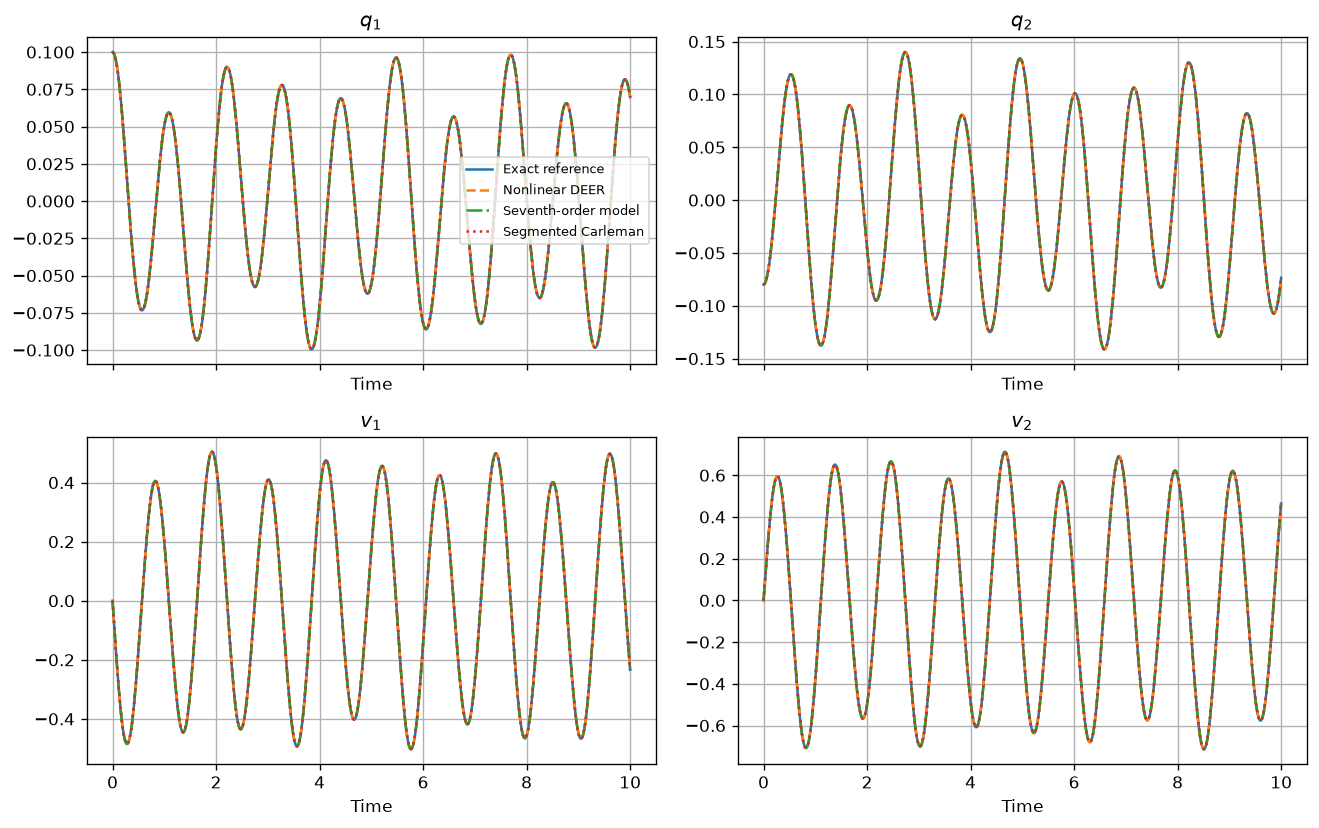

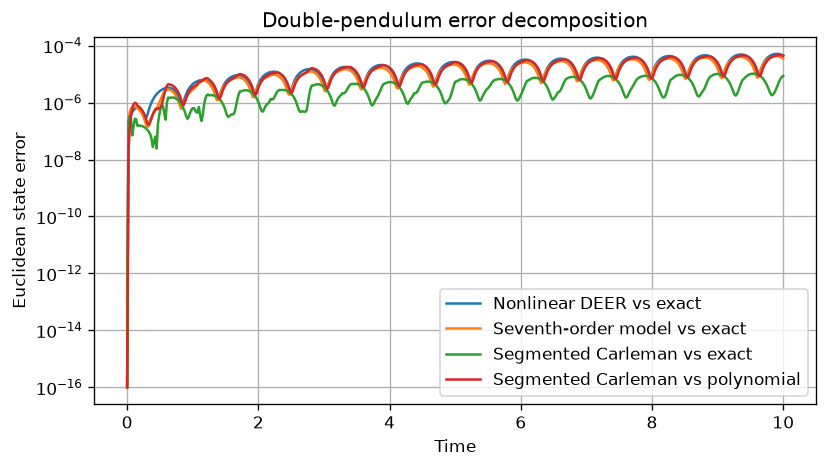

In [7]:
state_labels = (r"$q_1$", r"$q_2$", r"$v_1$", r"$v_2$")
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for state_index, axis in enumerate(axes.flat):
    axis.plot(times, reference[:, state_index], label="Exact reference")
    axis.plot(times, nonlinear_states[:, state_index], "--", label="Nonlinear DEER")
    axis.plot(times, polynomial_reference[:, state_index], "-.", label="Seventh-order model")
    axis.plot(times, carleman_states[:, state_index], ":", label="Segmented Carleman")
    axis.set_title(state_labels[state_index])
    axis.set_xlabel("Time")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

nonlinear_error = np.linalg.norm(nonlinear_states - reference, axis=1)
polynomial_error = np.linalg.norm(polynomial_reference - reference, axis=1)
carleman_exact_error = np.linalg.norm(carleman_states - reference, axis=1)
carleman_polynomial_error = np.linalg.norm(carleman_states - polynomial_reference, axis=1)
plt.figure(figsize=(7, 4))
plt.semilogy(times, np.maximum(nonlinear_error, 1e-16), label="Nonlinear DEER vs exact")
plt.semilogy(times, np.maximum(polynomial_error, 1e-16), label="Seventh-order model vs exact")
plt.semilogy(times, np.maximum(carleman_exact_error, 1e-16), label="Segmented Carleman vs exact")
plt.semilogy(times, np.maximum(carleman_polynomial_error, 1e-16), label="Segmented Carleman vs polynomial")
plt.xlabel("Time")
plt.ylabel("Euclidean state error")
plt.title("Double-pendulum error decomposition")
plt.legend()
plt.tight_layout()
plt.show()


## Truncation-order study

,Order,Lifted dimension,Maximum error vs exact,Maximum error vs seventh-order model,Final error vs exact
0,3,34,1.559479e-02,1.555395e-02,1.020736e-02
1,5,125,3.595256e-04,3.887843e-04,7.966118e-05
2,7,329,1.039569e-05,4.646705e-05,8.666121e-06


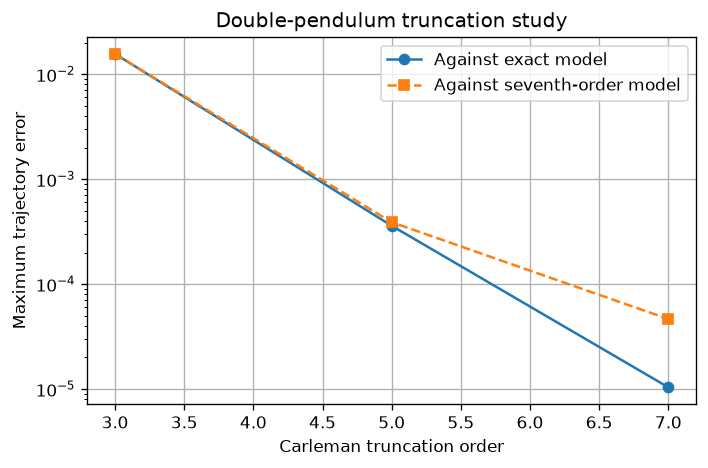

In [8]:
order_records = []
for order in (3, 5):
    matrix, exponents = double_pendulum_carleman_matrix(order)
    estimate = segmented_linear_trajectory(
        matrix=matrix,
        exponents=exponents,
        initial_state=x0_tensor,
        output_dimension=4,
        relift_steps=carleman_relift_steps,
    ).cpu().numpy()
    exact_metrics = trajectory_metrics(estimate, reference)
    polynomial_metrics = trajectory_metrics(estimate, polynomial_reference)
    order_records.append({
        "Order": order,
        "Lifted dimension": matrix.shape[0],
        "Maximum error vs exact": exact_metrics["Maximum error"],
        "Maximum error vs seventh-order model": polynomial_metrics["Maximum error"],
        "Final error vs exact": exact_metrics["Final error"],
    })

main_exact = trajectory_metrics(carleman_states, reference)
main_polynomial = trajectory_metrics(carleman_states, polynomial_reference)
order_records.append({
    "Order": carleman_order,
    "Lifted dimension": carleman_matrix.shape[0],
    "Maximum error vs exact": main_exact["Maximum error"],
    "Maximum error vs seventh-order model": main_polynomial["Maximum error"],
    "Final error vs exact": main_exact["Final error"],
})

order_table = pd.DataFrame(order_records)
display(order_table.style.format({
    "Maximum error vs exact": "{:.6e}",
    "Maximum error vs seventh-order model": "{:.6e}",
    "Final error vs exact": "{:.6e}",
}))
plt.figure(figsize=(6, 4))
plt.semilogy(order_table["Order"], order_table["Maximum error vs exact"], "o-", label="Against exact model")
plt.semilogy(order_table["Order"], order_table["Maximum error vs seventh-order model"], "s--", label="Against seventh-order model")
plt.xlabel("Carleman truncation order")
plt.ylabel("Maximum trajectory error")
plt.title("Double-pendulum truncation study")
plt.legend()
plt.tight_layout()
plt.show()
